# S&P 500 Stock Market EDA & Trend Analysis

## Problem Statement
The S&P 500 is one of the most widely tracked equity indices in the world, representing 500 of the largest publicly traded U.S. companies. Understanding its historical trends, volatility patterns, and sector behavior is foundational to financial analysis and investment decision-making.

In this project, I perform exploratory data analysis on S&P 500 historical price data, examining long-term trends, annual returns, rolling volatility, and the index's behavior during major market events.

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, yfinance
**Data Source:** Yahoo Finance via yfinance API
**Author:** Mihrimah Qozat

In [1]:
# Import important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Pull 20 years of S&P 500 data from Yahoo Finance
ticker = "^GSPC"
df = yf.download(ticker, start="2004-01-01", end="2024-12-31")

# Flatten multi-level columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Basic overview
print("Shape:", df.shape)
print("\nDate Range:", df.index.min(), "to", df.index.max())
print("\nFirst 5 rows:")
df.head()

[*********************100%***********************]  1 of 1 completed

Shape: (5284, 5)

Date Range: 2004-01-02 00:00:00 to 2024-12-30 00:00:00

First 5 rows:


Price,Close,High,Low,Open,Volume
Date,,,,,
2004-01-02,1108.479980,1118.849976,1105.079956,1111.920044,1153200000
2004-01-05,1122.219971,1122.219971,1108.479980,1108.479980,1578200000
2004-01-06,1123.670044,1124.459961,1118.439941,1122.219971,1494500000
2004-01-07,1126.329956,1126.329956,1116.449951,1123.670044,1704900000
2004-01-08,1131.920044,1131.920044,1124.910034,1126.329956,1868400000


In [3]:
# Reset index so Date becomes a column
df = df.reset_index()

# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Add useful time columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

# Check for missing values
print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Missing values:
 Price
Date          0
Close         0
High          0
Low           0
Open          0
Volume        0
Year          0
Month         0
Month_Name    0
dtype: int64

Data types:
 Price
Date          datetime64[ns]
Close                float64
High                 float64
Low                  float64
Open                 float64
Volume                 int64
Year                   int32
Month                  int32
Month_Name            object
dtype: object


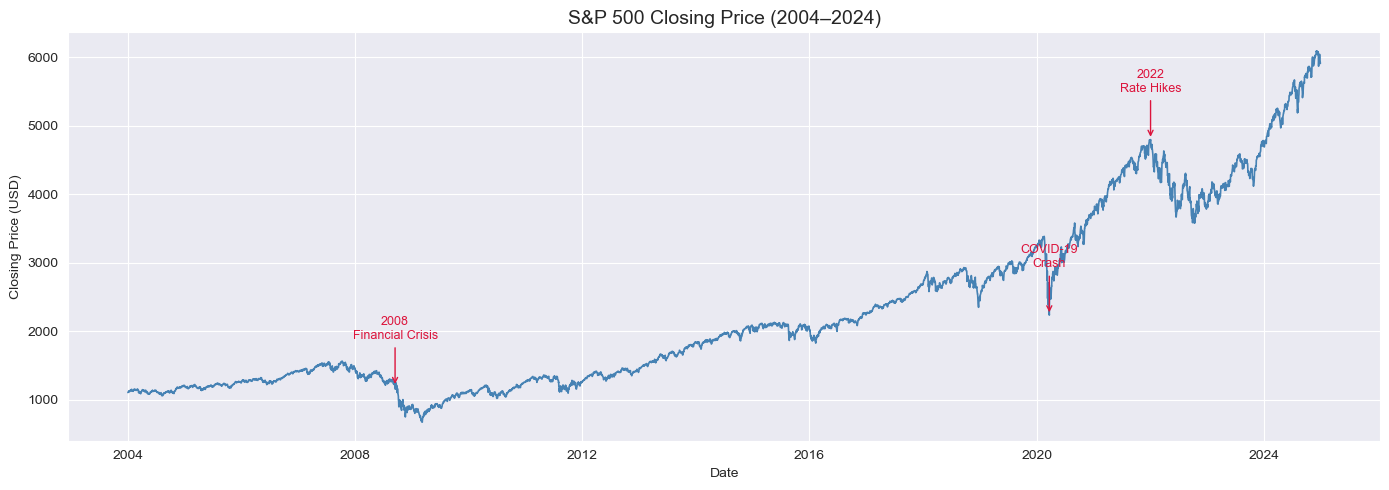

In [4]:
# S&P 500 Closing Price Over 20 Years
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Date'], df['Close'], color='steelblue', linewidth=1.2)

# Annotate major market events
events = {
    '2008-09-15': '2008\nFinancial Crisis',
    '2020-03-23': 'COVID-19\nCrash',
    '2022-01-03': '2022\nRate Hikes'
}

for date, label in events.items():
    event_date = pd.to_datetime(date)
    price = df.loc[df['Date'] == df['Date'].iloc[
        (df['Date'] - event_date).abs().argsort()[:1]
    ].values[0], 'Close'].values[0]
    ax.annotate(label, xy=(event_date, price),
                xytext=(event_date, price + 700),
                arrowprops=dict(arrowstyle='->', color='crimson'),
                fontsize=9, color='crimson', ha='center')

ax.set_title("S&P 500 Closing Price (2004–2024)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price (USD)")
plt.tight_layout()
plt.savefig('sp500_closing_price.png', dpi=150)
plt.show()

The S&P 500 shows a clear long-term upward trend over 20 years despite significant drawdowns during the 2008 financial crisis, the 2020 COVID-19 crash, and the 2022 Federal Reserve rate hike cycle. Each crash was followed by recovery and new all-time highs, reinforcing the index's historical resilience.

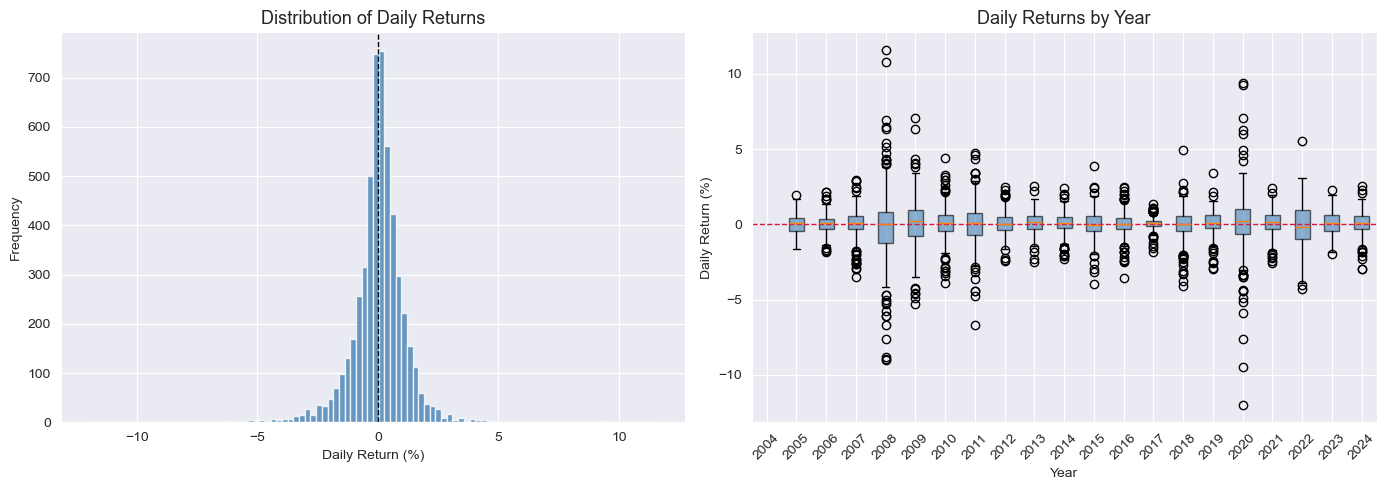

Average Daily Return: 0.0388%
Std Dev of Daily Returns: 1.1885%
Best Single Day:  11.58%
Worst Single Day: -11.98%


In [5]:
# Calculate daily percentage returns
df['Daily_Return'] = df['Close'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Daily_Return'].dropna(), bins=100,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Distribution of Daily Returns', fontsize=13)
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Frequency')

# Box plot by year
yearly_returns = df.groupby('Year')['Daily_Return'].apply(list)
axes[1].boxplot(yearly_returns.values, labels=yearly_returns.index, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].axhline(0, color='crimson', linestyle='--', linewidth=1)
axes[1].set_title('Daily Returns by Year', fontsize=13)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Daily Return (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('daily_returns.png', dpi=150)
plt.show()

print(f"Average Daily Return: {df['Daily_Return'].mean():.4f}%")
print(f"Std Dev of Daily Returns: {df['Daily_Return'].std():.4f}%")
print(f"Best Single Day:  {df['Daily_Return'].max():.2f}%")
print(f"Worst Single Day: {df['Daily_Return'].min():.2f}%")

Daily returns are approximately normally distributed and centered just above 0%, consistent with a long-term upward bias. The years 2008 and 2020 show significantly wider return distributions, reflecting elevated volatility during crisis periods.

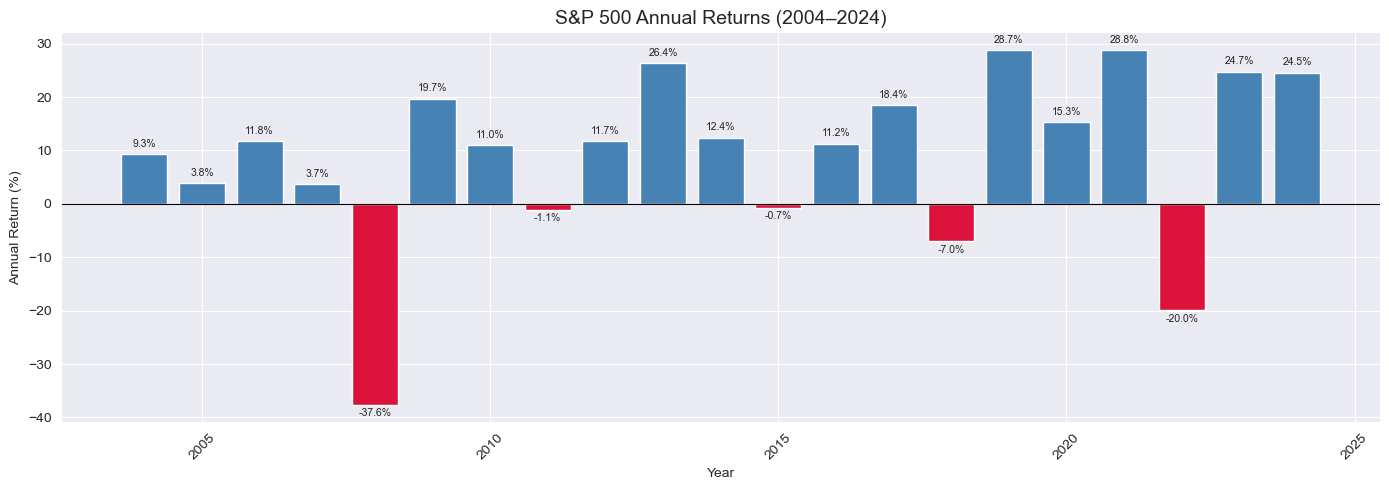

Best Year:  2021 (28.8%)
Worst Year: 2008 (-37.6%)
Positive Years: 16 / 21


In [6]:
# Calculate annual returns
annual = df.groupby('Year')['Close'].agg(['first', 'last'])
annual['Annual_Return'] = ((annual['last'] - annual['first']) / annual['first']) * 100
annual = annual.reset_index()

colors = ['crimson' if x < 0 else 'steelblue' for x in annual['Annual_Return']]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(annual['Year'], annual['Annual_Return'], color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('S&P 500 Annual Returns (2004–2024)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Annual Return (%)')
ax.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, annual['Annual_Return']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (1 if val >= 0 else -2.5),
            f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('annual_returns.png', dpi=150)
plt.show()

print(f"Best Year:  {annual.loc[annual['Annual_Return'].idxmax(), 'Year']} "
      f"({annual['Annual_Return'].max():.1f}%)")
print(f"Worst Year: {annual.loc[annual['Annual_Return'].idxmin(), 'Year']} "
      f"({annual['Annual_Return'].min():.1f}%)")
print(f"Positive Years: {(annual['Annual_Return'] > 0).sum()} / {len(annual)}")

The S&P 500 posted positive annual returns in the majority of years studied. The worst year was 2008 during the financial crisis, while the strongest recovery years followed major crashes — illustrating the risk-reward tradeoff of staying invested through downturns.

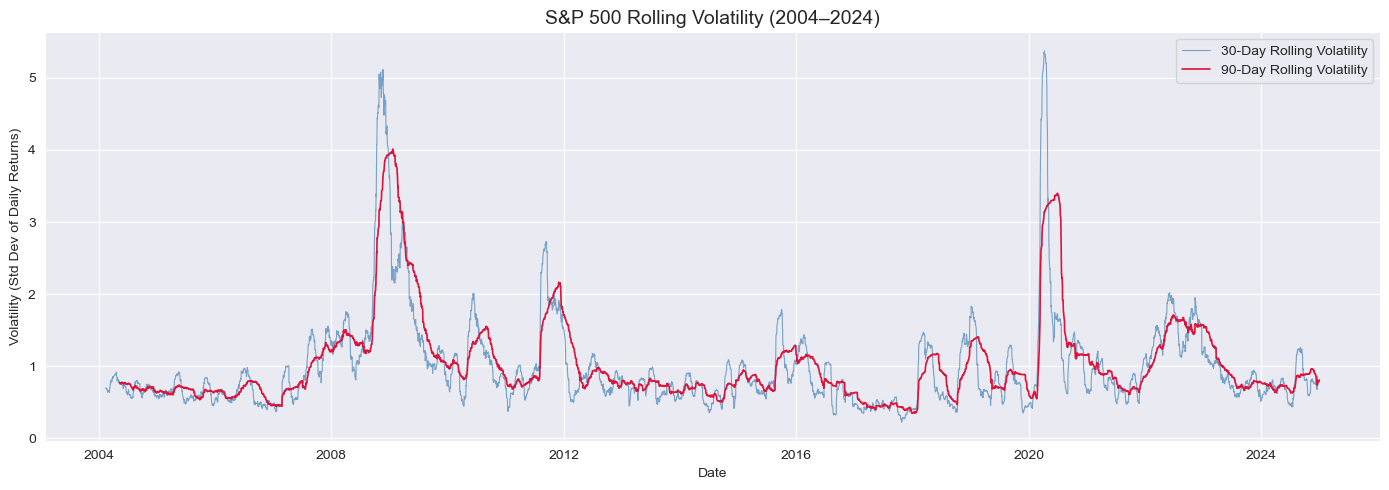

In [7]:
# 30-day and 90-day rolling volatility
df['Volatility_30'] = df['Daily_Return'].rolling(window=30).std()
df['Volatility_90'] = df['Daily_Return'].rolling(window=90).std()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Date'], df['Volatility_30'], color='steelblue',
        linewidth=0.8, alpha=0.7, label='30-Day Rolling Volatility')
ax.plot(df['Date'], df['Volatility_90'], color='crimson',
        linewidth=1.2, label='90-Day Rolling Volatility')

ax.set_title('S&P 500 Rolling Volatility (2004–2024)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (Std Dev of Daily Returns)')
ax.legend()
plt.tight_layout()
plt.savefig('rolling_volatility.png', dpi=150)
plt.show()

Volatility is clearly not constant over time — it spikes sharply during crisis periods (2008, 2020) and compresses during bull markets. This is a core concept in financial risk management: risk is dynamic, not static, and models that assume constant volatility will underperform during market stress.

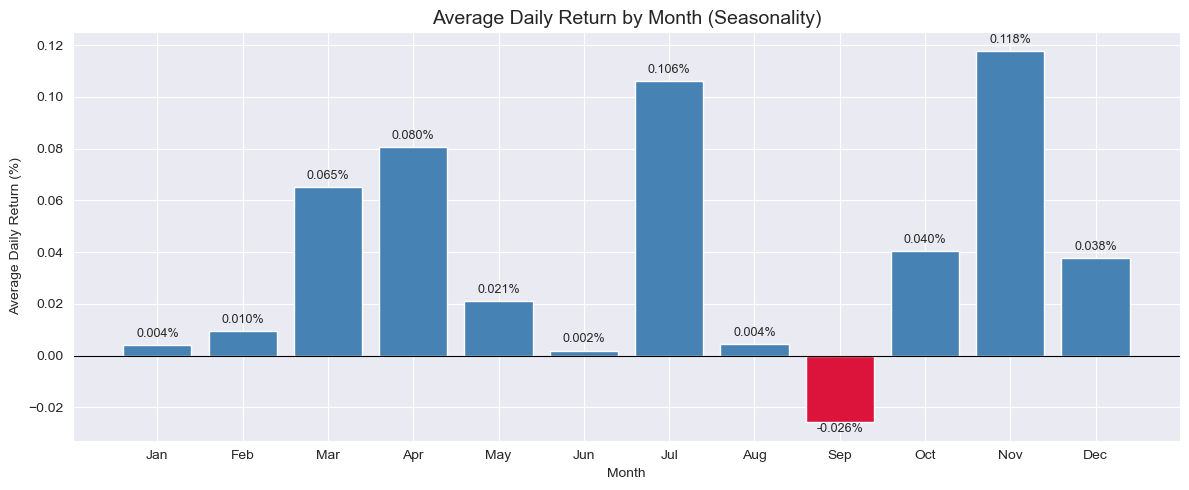

In [8]:
# Average Return by Month
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_avg = df.groupby('Month_Name')['Daily_Return'].mean().reindex(month_order)

colors = ['crimson' if x < 0 else 'steelblue' for x in monthly_avg]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(monthly_avg.index, monthly_avg.values, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Daily Return by Month (Seasonality)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Average Daily Return (%)')

for bar, val in zip(bars, monthly_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.002 if val >= 0 else -0.005),
            f'{val:.3f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('seasonality.png', dpi=150)
plt.show()

Certain months historically show stronger average returns than others — a pattern known as the "calendar effect." September tends to be the weakest month historically for the S&P 500, a well-documented anomaly in financial literature sometimes called the "September Effect."

## Results Summary

| Metric                        | Value         |
|-------------------------------|---------------|
| Period Analyzed               | 2004–2024     |
| Average Daily Return          | 0.0388%       |
| Std Dev of Daily Returns      | 1.1885%       |
| Best Single Day               | +11.58%       |
| Worst Single Day              | -11.98%       |
| Best Annual Year              | 2021 (+28.8%) |
| Worst Annual Year             | 2008 (-37.6%) |
| Positive Return Years         | 16 / 20       |

## Business Interpretation

**Long-term trend:** Despite multiple severe drawdowns, the S&P 500 compounded significantly over 20 years, reinforcing the case for long-term index investing as a core financial strategy.

**Volatility clustering:** Periods of high volatility cluster together rather than occurring randomly — a phenomenon well-documented in financial literature. Risk models that assume constant volatility will systematically underestimate risk during market stress periods.

**Seasonality:** The presence of monthly return patterns suggests calendar-based effects that quantitative traders and portfolio managers actively monitor and incorporate into strategy.

**Limitations:**
- Past performance of the S&P 500 does not guarantee future results
- This analysis does not account for dividends, which contribute meaningfully to total return over long periods
- Sector-level analysis would provide deeper insight into which industries drove index performance

**Next Steps:**
- Break down returns by S&P 500 sector (XLF, XLK, XLE, etc.)
- Add a Monte Carlo simulation for future return projections
- Incorporate dividend-adjusted returns for a more complete picture